# Thermal Gradient Figures

TODO:
1. transmission h->c, starting with 30 +- 0. 1 degree change every 3 min. Must be stable (within 0.5 deg of target) for at least 1 min. Ramp up, then down. (~90 min)
2. transmission c->h, starting with 30 +- 0. 1 degree change every 3 min. Must be stable (within 0.5 deg of target) for at least 1 min. ramp up, then down. (~90 min)
3. transmission h->c, both peltiers from 50 ->10. 5 degree change every 5 min. Must be stable (within 0.5 deg of target) for at least 1 min. Ramp down, then up. (~2hr)
4. transmission c->h, both peltiers from 50 ->10. 5 degree change every 5 min. Must be stable (within 0.5 deg of target) for at least 1 min. Ramp down, then up. (~2hr)

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..') # path to the src directory
sys.path.append('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonicTesting/')

import pickleJar as pj
import sqliteUtils as squ
import numpy as np
from numpy import fft
import os.path
import matplotlib.pyplot as plt

import ipywidgets

In [2]:
# First we load the data from the file we want to analyze
# The experiment should always output sqlite3 files, so let's convert them to a more usable pickle form first
sqliteFile = "/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/LMFP_Cu_gradient.sqlite3"

# Convert the sqlite3 to a .pickle
# This takes a few seconds. A progress bar will display in your terminal
pj.sqliteToPickle(sqliteFile)

# Load the pickle
pickleFile = os.path.splitext(sqliteFile)[0] + '.pickle'

data = pj.loadPickle("/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/LMFP_Cu_gradient.pickle")
data['parameters']['dt'] = data['parameters']['measureTime']-data['parameters']['measureDelay'] *10-6/ data['parameters']['samples']

sqliteToPickle Warning: pickle file /Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/LMFP_Cu_gradient.pickle already exists. Conversion aborted.


In [3]:
data['parameters']

{'gui': 0.0,
 'experiment': 'repeat pulse',
 'axis': 'z',
 'distance': 75.0,
 'transducerFrequency': 2.25,
 'collectionMode': 'transmission',
 'pulserType': 'standard',
 'measureTime': 20.0,
 'measureDelay': 0.0,
 'voltageRange': 2.0,
 'autoRange': 'True',
 'autoRangeEcho': 'True',
 'waves': 100.0,
 'samples': 10000.0,
 'halfCycles': 2.0,
 'multiplexer': 'False',
 'collectionDirection': 'both',
 'voltageOffsetForward': 0.0,
 'voltageOffsetReverse': 0.0,
 'gainForward': 500.0,
 'gainReverse': 500.0,
 'picoModule': 1.0,
 'pulseModule': 0.0,
 'rfSwitch': 2.0,
 't0PulseSwitch': 0.0,
 't0ReceiveSwitch': 0.0,
 't1PulseSwitch': 1.0,
 't1ReceiveSwitch': 1.0,
 'experimentFolder': 'C://Users//changlab//Desktop//UT Data//toy_data//',
 'experimentName': 'LMFP_Cu_gradient',
 'experimentBaseName': 'test_multiscan_data',
 'saveFormat': 'sqlite',
 'postAnalysis': 'False',
 'primaryAxis': 'X',
 'secondaryAxis': 'Z',
 'primaryAxisRange': 25.0,
 'primaryAxisStep': 1.0,
 'secondaryAxisRange': 25.0,
 'seco

In [4]:
data[0].keys()

dict_keys(['voltage', 'time', 'time_collected', 'collection_index'])

In [5]:
data['dt'] = (data['parameters']['measureTime']-data['parameters']['measureDelay'])/data['parameters']['samples']
data['dt']

0.002

## Merge the waveform and controller data wrt time that UT is running

In [6]:
def correct_voltage(dataframe):
    '''correct measurements by matching mean of 1st 25 pts to 0.
    '''
    for item in dataframe['voltage']:
        item -= item[:25].mean()
    return dataframe

In [7]:
import pandas as pd
measurements = {k:v for k,v in data.items() if isinstance(k, int)}
waveform_df = pd.DataFrame(measurements).transpose()
waveform_df = correct_voltage(waveform_df)
waveform_df

,voltage,time,time_collected,collection_index
0,"[1.1304995078740157, 1.0008550688976376, 0.914...","[0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16...",1781647963.975113,0.0
1,"[1.092476624015748, 0.53068405511811, 0.789972...","[0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16...",1781647964.634479,1.0
2,"[1.4226377952755906, 0.3854822834645668, 0.644...","[0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16...",1781647965.633091,2.0
3,"[0.9403604822834645, 0.8107160433070866, 0.637...","[0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16...",1781647966.637185,3.0
4,"[1.2307640255905512, 0.9282603346456691, 0.625...","[0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16...",1781647967.647445,4.0
...,...,...,...,...
3592,"[0.7056471456692917, 0.6192175196850389, 0.100...","[0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16...",1781651559.288816,3592.0
3593,"[0.7295398622047244, 0.6000492125984245, -0.48...","[0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16...",1781651560.284007,3593.0
3594,"[0.6639333169291337, 0.8800073818897642, 0.274...","[0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16...",1781651561.285767,3594.0
3595,"[0.9661724901574806, 0.3614726870078737, 0.188...","[0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16...",1781651562.276402,3595.0


In [8]:
## Read in monitor data, add ms to time
from datetime import datetime
controller_monitor_df = pd.read_csv('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/CoSo_2026-06-16_19-14-58 (all)_Monitor.csv',
                            delimiter=';',
                            usecols=[   'Time', 'Milliseconds',
                                        '1000.1: CH1 Object', '1000.2: CH2 Object', # ###.#: is the firmware output for that channel.
                                        '1001.1: CH1 Sink', '1001.2: CH2 Sink',
                                        '1045.1: HR1 Temp', '1045.2: HR2 Temp',
                                        '1044.1: LR1 Temp', '1044.2: LR2 Temp',
                                        '3000.1: CH1 Target', '3000.2: CH2 Target',
                                    ])
controller_monitor_df['Time_str'] = controller_monitor_df['Time']
controller_monitor_df['Time'] = controller_monitor_df['Time'].apply(lambda x: datetime.strptime(x, '%m/%d/%Y %I:%M:%S %p').timestamp())
controller_monitor_df['Time'] += controller_monitor_df['Milliseconds']/1000
controller_monitor_df.drop(columns=['Milliseconds'], inplace=True)

## Read in settings data, add ms to time
controller_settings_df = pd.read_csv('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/CoSo_2026-06-16_19-14-58 (all)_Settings.csv',

                            delimiter=';',
                            usecols=[   'Time', 'Milliseconds',
                                        '2010.1: Output Enable', '2010.2: Output Enable', 
                                        '3034.1: Peltier Polarity', '3034.2: Peltier Polarity',
                                        '1200.1: Temperature is Stable','1200.2: Temperature is Stable'
                                    ])

# to correct later: PID params, max temperature change, )
controller_settings_df['Time'] = controller_settings_df['Time'].apply(lambda x: datetime.strptime(x, '%m/%d/%Y %I:%M:%S %p').timestamp())
controller_settings_df['Time'] += controller_settings_df['Milliseconds']/1000
controller_settings_df.drop(columns=['Milliseconds'], inplace=True)

## Merge monitor and settings data
controller_df = pd.merge_asof(
    left=controller_monitor_df,
    right=controller_settings_df,
    left_on='Time',
    right_on='Time',
    direction='nearest' 
)
## Convert time to float in all dfs
waveform_df['time_collected'] = waveform_df['time_collected'].astype(float)
controller_monitor_df['Time'] = controller_monitor_df['Time'].astype(float)
controller_settings_df['Time'] = controller_settings_df['Time'].astype(float)

## Merge waveform and controller data
merged_df = pd.merge_asof(
    left=waveform_df,
    right=controller_df,
    left_on='time_collected',
    right_on='Time',
    direction='nearest' 
)
## reformat time Time_str to '%m/%d/%y %H:%M:%S'
merged_df['Time_str'] = pd.to_datetime(merged_df['Time_str']).dt.strftime('%m/%d/%y %H:%M:%S')
merged_df.to_csv('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/merged_df.csv')

/var/folders/vg/g8h80y317zj5sfz8_f4l85wddxx210/T/ipykernel_71654/891025826.py:54: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged_df['Time_str'] = pd.to_datetime(merged_df['Time_str']).dt.strftime('%m/%d/%y %H:%M:%S')


In [9]:
merged_df.tail()

,voltage,time,time_collected,collection_index,Time,1000.1: CH1 Object,1000.2: CH2 Object,1001.1: CH1 Sink,1001.2: CH2 Sink,1044.1: LR1 Temp,...,1045.2: HR2 Temp,3000.1: CH1 Target,3000.2: CH2 Target,Time_str,1200.1: Temperature is Stable,1200.2: Temperature is Stable,2010.1: Output Enable,2010.2: Output Enable,3034.1: Peltier Polarity,3034.2: Peltier Polarity
3592,"[0.7056471456692917, 0.6192175196850389, 0.100...","[0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16...",1.781652e+09,3592.0,1.781652e+09,17.570520,31.657495,34.166862,27.165308,34.166862,...,31.657495,17.0,43.0,06/16/26 19:12:39,1,0,ON,ON,Cooling,Cooling
3593,"[0.7295398622047244, 0.6000492125984245, -0.48...","[0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16...",1.781652e+09,3593.0,1.781652e+09,17.441278,32.011375,34.096581,27.103754,34.096581,...,32.011375,17.0,43.0,06/16/26 19:12:40,1,0,ON,ON,Cooling,Cooling
3594,"[0.6639333169291337, 0.8800073818897642, 0.274...","[0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16...",1.781652e+09,3594.0,1.781652e+09,16.882532,32.342278,34.029167,27.043238,34.029167,...,32.342278,17.0,43.0,06/16/26 19:12:41,1,0,ON,ON,Cooling,Cooling
3595,"[0.9661724901574806, 0.3614726870078737, 0.188...","[0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16...",1.781652e+09,3595.0,1.781652e+09,17.567316,32.734367,33.961998,26.984400,33.961998,...,32.734367,17.0,43.0,06/16/26 19:12:42,1,0,ON,ON,Cooling,Cooling
3596,"[0.39613065944881853, 0.8716473917322829, -0.0...","[0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16...",1.781652e+09,3596.0,1.781652e+09,17.546747,33.140373,33.892967,26.924463,33.892967,...,33.140373,17.0,43.0,06/16/26 19:12:43,1,0,ON,ON,Cooling,Cooling


## Compare Curves of gradients vs means

In [10]:
merged_df['index'] = merged_df.index
merged_df['means'] = merged_df[['1000.1: CH1 Object', '1000.2: CH2 Object']].mean(axis=1)
merged_df['diff'] = merged_df['1000.2: CH2 Object'] - merged_df['1000.1: CH1 Object']
merged_df['amplitude'] = list(map(pj.maxMinusMin, merged_df['voltage']))
merged_df['Simple ToF'] = list(map(pj.simpleThresholdTOF, merged_df['voltage'], merged_df['time'], [0.1,] * len(merged_df)))
merged_df['Hilbert ToF'] = list(map(pj.envelopeThresholdTOF, merged_df['voltage'], merged_df['time'], [0.1,] * len(merged_df)))

In [11]:
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
from datetime import datetime
import matplotlib.cm as cm

def plot_waveform(i):
    plt.figure(figsize=(8, 4))
    plt.plot(merged_df['time'][i], merged_df['voltage'][i], lw=1, label='Transmission')
    plt.vlines(merged_df['Simple ToF'][i], -450, 450, color='red', lw=1, linestyles='--', label='Simple ToF')
    plt.vlines(merged_df['Hilbert ToF'][i], -450, 450, color='blue', lw=1, linestyles='--', label='Hilbert ToF')
    plt.title(f'Measurement {i} at ({merged_df["Time_str"][i]})')
    plt.ylim(-450, 450)
    plt.xlabel('Time (ns)')
    plt.ylabel('Voltage (mV)')
    plt.legend()
    plt.tight_layout()
    plt.show()

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(merged_df)-1,
    step=1,
    description='measurement:',
    continuous_update=False
)

interact(plot_waveform, i=slider)

interactive(children=(IntSlider(value=0, continuous_update=False, description='measurement:', max=3596), Outpu…

<function __main__.plot_waveform(i)>

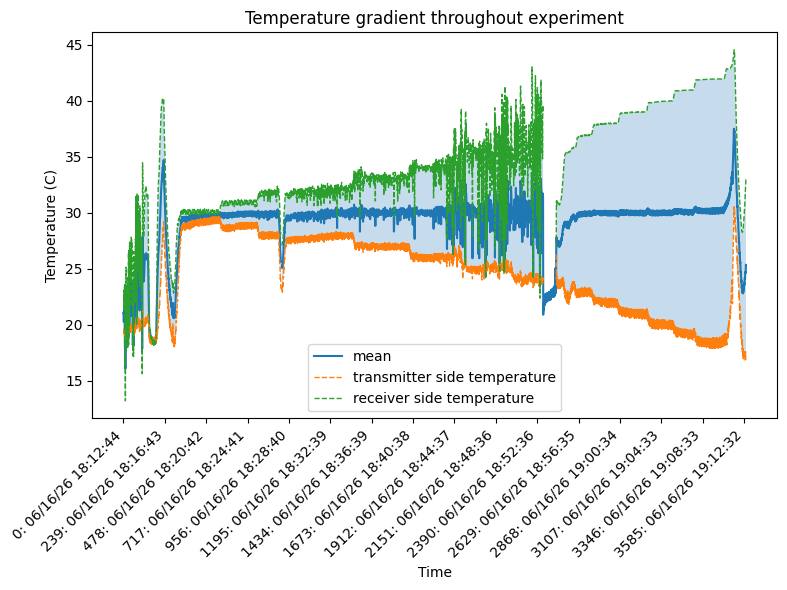

In [12]:
xticks_labels = merged_df['index'].astype(str) + ': ' + merged_df['Time_str']

plt.figure(figsize=(8, 6))
# plt.plot(xticks_labels, merged_df['diff'], label='difference')
plt.plot(xticks_labels, merged_df['means'], label='mean')
lower_bound = merged_df['means'] - merged_df['diff'] / 2
plt.plot(xticks_labels, lower_bound, label='transmitter side temperature', linewidth=1, linestyle='--')
upper_bound = merged_df['means'] + merged_df['diff'] / 2
plt.plot(xticks_labels, upper_bound, label='receiver side temperature', linewidth=1, linestyle='--')

plt.fill_between(
    xticks_labels,
    lower_bound,
    upper_bound,  # Upper half
    alpha=0.25,
    )

plt.title('Temperature gradient throughout experiment')
plt.xlabel('Time')
plt.ylabel('Temperature (C)')
plt.legend()
plt.xticks(ticks=range(0, len(xticks_labels), max(1, len(xticks_labels)//15)), labels=xticks_labels[::max(1, len(xticks_labels)//15)], rotation=45, ha='right')
plt.tight_layout()
plt.show()

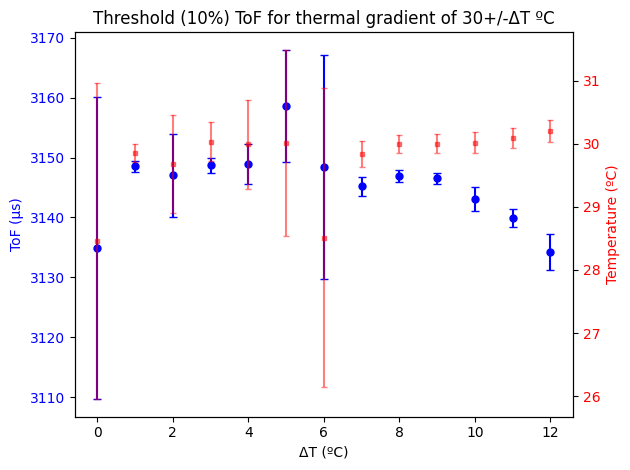

In [14]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()  # second y-axis sharing x-axis

for i in range(13):
    mask =  (merged_df['3000.1: CH1 Target'] == 30-i) & \
            (merged_df['3000.2: CH2 Target'] == 30+i) & \
            (merged_df['2010.1: Output Enable'] == 'ON') & \
            (merged_df['2010.2: Output Enable'] == 'ON')
    filtered_df = merged_df[mask]
    
    if filtered_df.empty: continue
    
    tof_mean = filtered_df['Simple ToF'].mean()
    tof_std = filtered_df['Simple ToF'].std()
    ax1.errorbar(i, tof_mean, yerr=tof_std, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
    
    t_mean = filtered_df['means'].mean()
    t_std = filtered_df['means'].std()
    ax2.errorbar(i, t_mean, yerr=t_std, fmt='s', markersize=3, color='red', ecolor='red', capsize=2, alpha=0.5)

ax1.set_xlabel('ΔT (ºC)')
ax1.set_ylabel('ToF (μs)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2.set_ylabel('Temperature (ºC)', color='red')  # update label as appropriate
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Threshold (10%) ToF for thermal gradient of 30+/-ΔT ºC')
plt.tight_layout()


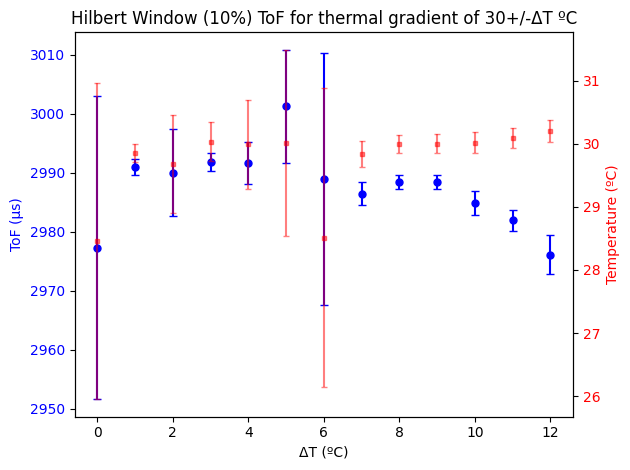

In [15]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()  # second y-axis sharing x-axis

for i in range(13):
    mask =  (merged_df['3000.1: CH1 Target'] == 30-i) & \
            (merged_df['3000.2: CH2 Target'] == 30+i) & \
            (merged_df['2010.1: Output Enable'] == 'ON') & \
            (merged_df['2010.2: Output Enable'] == 'ON')
    filtered_df = merged_df[mask]
    
    if filtered_df.empty: continue
    
    tof_mean = filtered_df['Hilbert ToF'].mean()
    tof_std = filtered_df['Hilbert ToF'].std()
    ax1.errorbar(i, tof_mean, yerr=tof_std, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
    
    t_mean = filtered_df['means'].mean()
    t_std = filtered_df['means'].std()
    ax2.errorbar(i, t_mean, yerr=t_std, fmt='s', markersize=3, color='red', ecolor='red', capsize=2, alpha=0.5)

ax1.set_xlabel('ΔT (ºC)')
ax1.set_ylabel('ToF (μs)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2.set_ylabel('Temperature (ºC)', color='red')  # update label as appropriate
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Hilbert Window (10%) ToF for thermal gradient of 30+/-ΔT ºC')
plt.tight_layout()


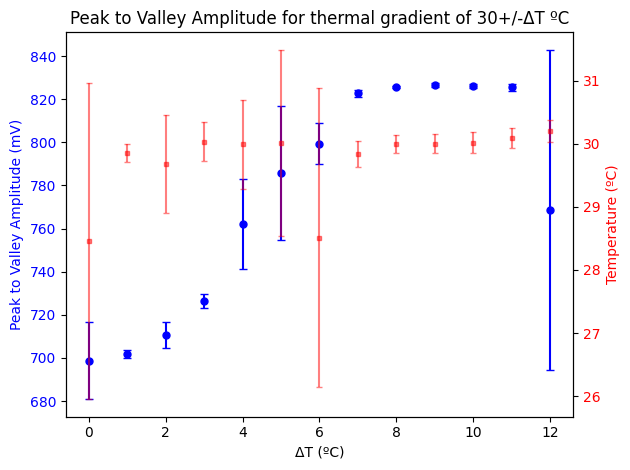

In [16]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()  # second y-axis sharing x-axis

for i in range(13):
    mask =  (merged_df['3000.1: CH1 Target'] == 30-i) & \
            (merged_df['3000.2: CH2 Target'] == 30+i) & \
            (merged_df['2010.1: Output Enable'] == 'ON') & \
            (merged_df['2010.2: Output Enable'] == 'ON')
    filtered_df = merged_df[mask]
    
    if filtered_df.empty: continue
    
    tof_mean = filtered_df['amplitude'].mean()
    tof_std = filtered_df['amplitude'].std()
    ax1.errorbar(i, tof_mean, yerr=tof_std, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
    
    t_mean = filtered_df['means'].mean()
    t_std = filtered_df['means'].std()
    ax2.errorbar(i, t_mean, yerr=t_std, fmt='s', markersize=3, color='red', ecolor='red', capsize=2, alpha=0.5)

ax1.set_xlabel('ΔT (ºC)')
ax1.set_ylabel('Peak to Valley Amplitude (mV)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2.set_ylabel('Temperature (ºC)', color='red')  # update label as appropriate
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Peak to Valley Amplitude for thermal gradient of 30+/-ΔT ºC')
plt.tight_layout()


## Filter out outliers (+/- 5 from target)

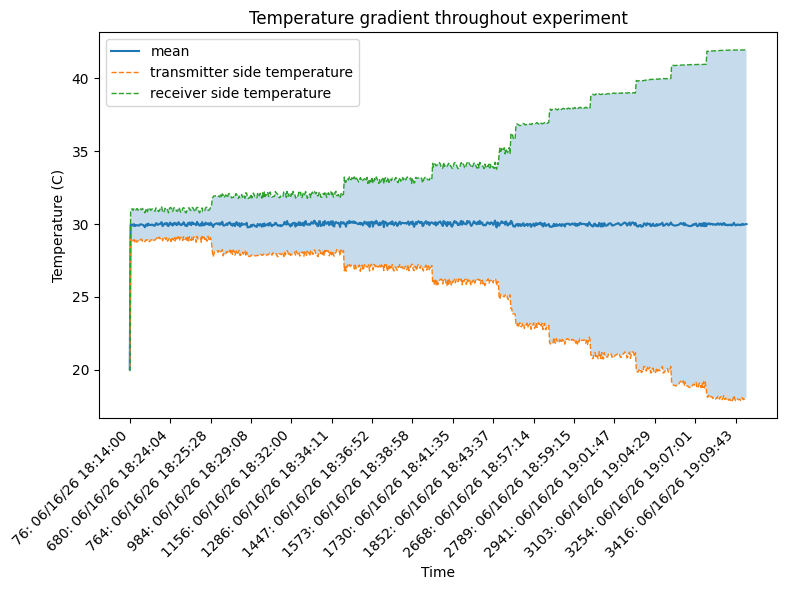

In [13]:
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
from datetime import datetime

mask = ( (merged_df['1000.1: CH1 Object'] - merged_df['3000.1: CH1 Target']).abs() < 0.25  
   ) & ( (merged_df['1000.2: CH2 Object'] - merged_df['3000.2: CH2 Target']).abs() < 0.25 )

merged_filtered_df = merged_df.loc[mask].copy()

xticks_labels = merged_filtered_df['index'].astype(str) + ': ' + merged_filtered_df['Time_str']

plt.figure(figsize=(8, 6))
# plt.plot(xticks_labels, merged_df['diff'], label='difference')
plt.plot(xticks_labels, merged_filtered_df['means'], label='mean')
lower_bound = merged_filtered_df['means'] - merged_filtered_df['diff'] / 2
plt.plot(xticks_labels, lower_bound, label='transmitter side temperature', linewidth=1, linestyle='--')
upper_bound = merged_filtered_df['means'] + merged_filtered_df['diff'] / 2
plt.plot(xticks_labels, upper_bound, label='receiver side temperature', linewidth=1, linestyle='--')

plt.fill_between(
    xticks_labels,
    lower_bound,
    upper_bound,  # Upper half
    alpha=0.25,
    )

plt.title('Temperature gradient throughout experiment')
plt.xlabel('Time')
plt.ylabel('Temperature (C)')
plt.legend()
plt.xticks(ticks=range(0, len(xticks_labels), max(1, len(xticks_labels)//15)), labels=xticks_labels[::max(1, len(xticks_labels)//15)], rotation=45, ha='right')
plt.tight_layout()
plt.show()

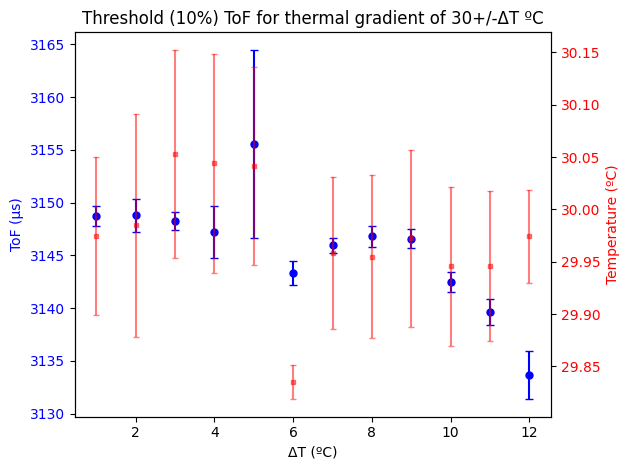

In [18]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()  # second y-axis sharing x-axis

for i in range(13):
    mask =  (merged_filtered_df['3000.1: CH1 Target'] == 30-i) & \
            (merged_filtered_df['3000.2: CH2 Target'] == 30+i) & \
            (merged_filtered_df['2010.1: Output Enable'] == 'ON') & \
            (merged_filtered_df['2010.2: Output Enable'] == 'ON')
    filtered_df = merged_filtered_df[mask]
    
    if filtered_df.empty: continue
    
    tof_mean = filtered_df['Simple ToF'].mean()
    tof_std = filtered_df['Simple ToF'].std()
    ax1.errorbar(i, tof_mean, yerr=tof_std, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
    
    t_mean = filtered_df['means'].mean()
    t_std = filtered_df['means'].std()
    ax2.errorbar(i, t_mean, yerr=t_std, fmt='s', markersize=3, color='red', ecolor='red', capsize=2, alpha=0.5)

ax1.set_xlabel('ΔT (ºC)')
ax1.set_ylabel('ToF (μs)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2.set_ylabel('Temperature (ºC)', color='red')  # update label as appropriate
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Threshold (10%) ToF for thermal gradient of 30+/-ΔT ºC')
plt.tight_layout()

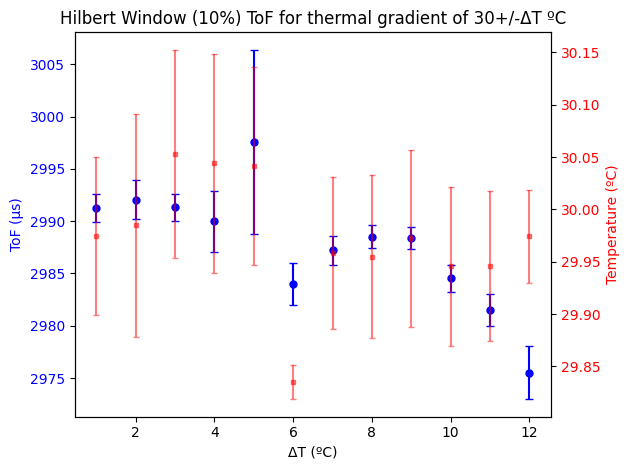

In [19]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()  # second y-axis sharing x-axis

for i in range(13):
    mask =  (merged_filtered_df['3000.1: CH1 Target'] == 30-i) & \
            (merged_filtered_df['3000.2: CH2 Target'] == 30+i) & \
            (merged_filtered_df['2010.1: Output Enable'] == 'ON') & \
            (merged_filtered_df['2010.2: Output Enable'] == 'ON')
    filtered_df = merged_filtered_df[mask]
    
    if filtered_df.empty: continue
    
    tof_mean = filtered_df['Hilbert ToF'].mean()
    tof_std = filtered_df['Hilbert ToF'].std()
    ax1.errorbar(i, tof_mean, yerr=tof_std, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
    
    t_mean = filtered_df['means'].mean()
    t_std = filtered_df['means'].std()
    ax2.errorbar(i, t_mean, yerr=t_std, fmt='s', markersize=3, color='red', ecolor='red', capsize=2, alpha=0.5)

ax1.set_xlabel('ΔT (ºC)')
ax1.set_ylabel('ToF (μs)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2.set_ylabel('Temperature (ºC)', color='red')  # update label as appropriate
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Hilbert Window (10%) ToF for thermal gradient of 30+/-ΔT ºC')
plt.tight_layout()

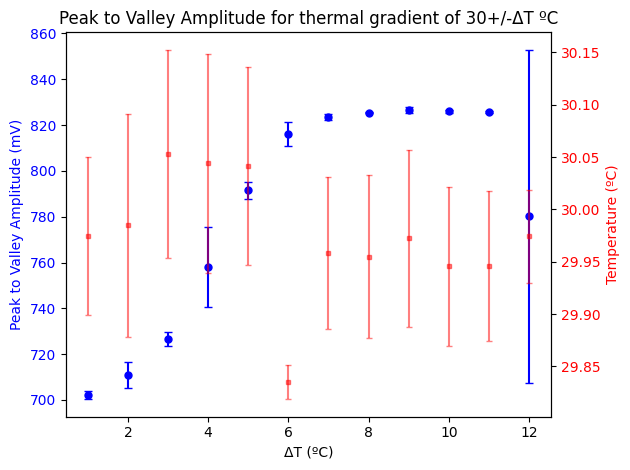

In [20]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()  # second y-axis sharing x-axis

for i in range(13):
    mask =  (merged_filtered_df['3000.1: CH1 Target'] == 30-i) & \
            (merged_filtered_df['3000.2: CH2 Target'] == 30+i) & \
            (merged_filtered_df['2010.1: Output Enable'] == 'ON') & \
            (merged_filtered_df['2010.2: Output Enable'] == 'ON')
    filtered_df = merged_filtered_df[mask]
    
    if filtered_df.empty: continue
    
    tof_mean = filtered_df['amplitude'].mean()
    tof_std = filtered_df['amplitude'].std()
    ax1.errorbar(i, tof_mean, yerr=tof_std, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
    
    t_mean = filtered_df['means'].mean()
    t_std = filtered_df['means'].std()
    ax2.errorbar(i, t_mean, yerr=t_std, fmt='s', markersize=3, color='red', ecolor='red', capsize=2, alpha=0.5)

ax1.set_xlabel('ΔT (ºC)')
ax1.set_ylabel('Peak to Valley Amplitude (mV)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2.set_ylabel('Temperature (ºC)', color='red')  # update label as appropriate
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Peak to Valley Amplitude for thermal gradient of 30+/-ΔT ºC')
plt.tight_layout()

## filtered by mean temperature

In [21]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

/var/folders/vg/g8h80y317zj5sfz8_f4l85wddxx210/T/ipykernel_24482/1552285467.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))


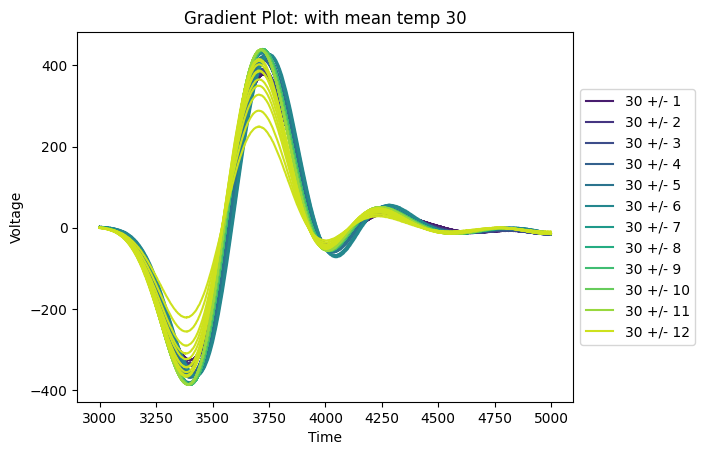

In [22]:
x_lims = [1500,2500]

for i in range(13):
    mask = (merged_filtered_df['3000.1: CH1 Target'] == 30-i) & (merged_filtered_df['3000.2: CH2 Target'] == 30+i)
    for idx, row in merged_filtered_df.loc[mask].iloc[-10:].iterrows():
        plt.plot(
            row['time'][x_lims[0]:x_lims[1]],
            row['voltage'][x_lims[0]:x_lims[1]],
            color=cm.viridis(i / 13),
            label=f'30 +/- {i}' if idx == merged_filtered_df.loc[mask].index[-1] else None
        )
    plt.xlabel('Time')
    plt.ylabel('Voltage')
    plt.title(f'Gradient Plot: with mean temp 30')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))